In [21]:
# pip install statsmodels
# !pip install pmdarima
# !pip install fbprophet

In [22]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from pmdarima import auto_arima



# 1. Carregar os dados

# Carregar dados
data = {'timestamp': ['2023-10-01', '2023-10-08', '2023-10-15', '2023-10-22', '2023-10-29', '2023-11-05', 
                      '2023-11-12', '2023-11-19', '2023-11-26', '2023-12-03', '2023-12-10', '2023-12-17', 
                      '2023-12-24', '2023-12-31', '2024-01-07', '2024-01-14', '2024-01-21', '2024-01-28', 
                      '2024-02-04', '2024-02-11', '2024-02-18', '2024-02-25', '2024-03-03', '2024-03-10', 
                      '2024-03-17', '2024-03-24', '2024-03-31', '2024-04-07', '2024-04-14', '2024-04-21', 
                      '2024-04-28', '2024-05-05', '2024-05-12'],
        'kWh': [39153.24, 141320.52, 146671.56, 124645.32, 146279.52, 145839.96, 147657.6, 138212.64, 
                147140.64, 148873.32, 143710.92, 145474.56, 147323.52, 147251.52, 145724.76, 143252.64, 
                135256.32, 139863.6, 143287.56, 144475.92, 144952.92, 144999.36, 145198.8, 121432.68, 
                145365.84, 138715.56, 130745.16, 145145.88, 142728.48, 146224.08, 139841.28, 134984.16, 
                129655.08]}

data_validation = {'timestamp': ['2024-05-19', '2024-05-26', '2024-06-02', 
                      '2024-06-09', '2024-06-16', '2024-06-23', '2024-06-30', '2024-07-07', '2024-07-14', 
                      '2024-07-21', '2024-07-28', '2024-08-04'],
                     'kWh': [153489.96, 153509.4, 152628.48, 155270.52, 154617.12, 154979.64, 148713.48, 156238.92, 149474.16, 156655.44, 160405.56, 62075.88]}

In [23]:
df = pd.DataFrame(data)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# 2. Ajustar o modelo ARIMA
model = ARIMA(df['kWh'], order=(2, 0, 3))
model_fit = model.fit()

# 3. Prever múltiplos passos à frente
forecast = model_fit.forecast(steps=12)
print(forecast)

c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autor

2024-05-19    146250.707170
2024-05-26    138273.139269
2024-06-02    136924.850328
2024-06-09    140967.507005
2024-06-16    134913.930642
2024-06-23    141960.655500
2024-06-30    135101.771905
2024-07-07    140626.523873
2024-07-14    137355.930033
2024-07-21    137831.801970
2024-07-28    140222.427823
2024-08-04    135373.010418
Freq: W-SUN, Name: predicted_mean, dtype: float64


c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


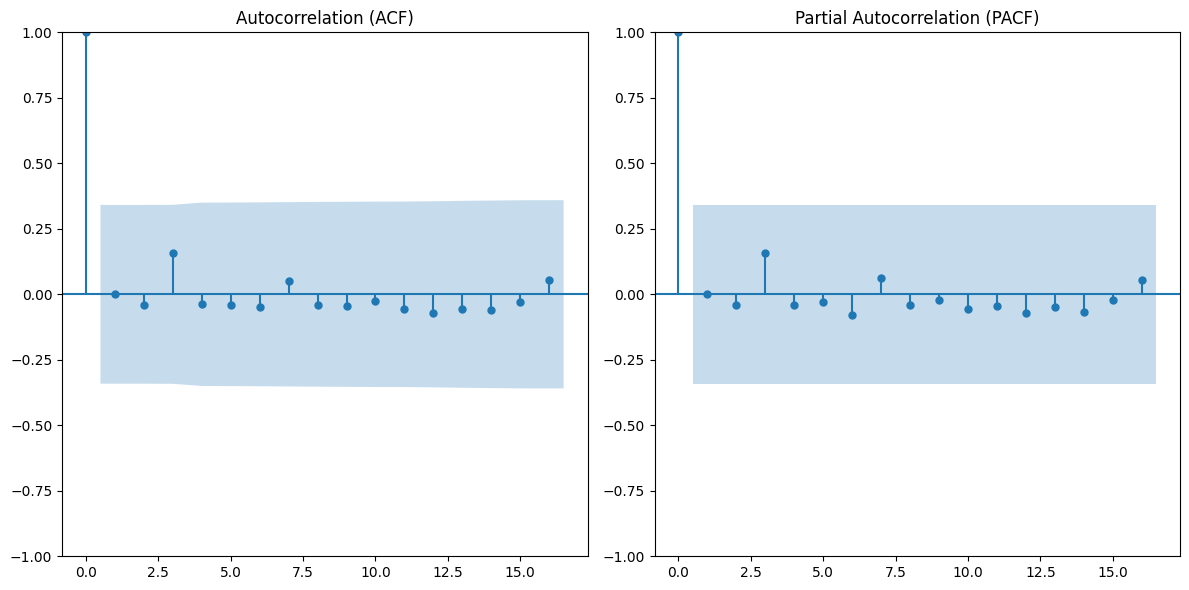

In [24]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Função para plotar ACF e PACF
def plot_acf_pacf(data, lags=16):
    """
    Plota os gráficos de ACF e PACF da série temporal.
    
    Parâmetros:
    - data: série temporal (pandas Series)
    - lags: número de lags a serem considerados nos gráficos (default = 20)
    """
    plt.figure(figsize=(12, 6))
    
    # Plot ACF
    plt.subplot(1, 2, 1)
    plot_acf(data, lags=lags, ax=plt.gca())
    plt.title("Autocorrelation (ACF)")
    
    # Plot PACF
    plt.subplot(1, 2, 2)
    plot_pacf(data, lags=lags, ax=plt.gca())
    plt.title("Partial Autocorrelation (PACF)")
    
    plt.tight_layout()
    plt.show()

# Chamando a função para plotar ACF e PACF
plot_acf_pacf(df['kWh'])

In [25]:
# Função para ajustar ARIMA automaticamente
def auto_arima_model(data):
    """
    Encontra automaticamente os melhores parâmetros p, d, q para o modelo ARIMA.
    
    Parâmetros:
    - data: série temporal (pandas Series)
    
    Retorna:
    - modelo ajustado ARIMA
    """
    # Encontra os melhores parâmetros ARIMA automaticamente
    model = auto_arima(data, 
                       start_p=1, start_q=1,
                       max_p=5, max_q=5,
                       d=None,       # Determina d automaticamente
                       seasonal=False,  # Define como ARIMA (não SARIMA)
                       trace=True,   # Mostra o progresso do ajuste
                       error_action='ignore',  
                       suppress_warnings=True, 
                       stepwise=True)  # Otimização mais eficiente
                       
    # Exibe o sumário do modelo
    print(model.summary())
    
    return model

# Chamando a função de auto_arima para otimizar o modelo
auto_arima_model(df['kWh'])

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=inf, Time=0.23 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=877.613, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=755.572, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=858.571, Time=0.04 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=905.090, Time=0.02 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 0.456 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   33
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -375.786
Date:                Fri, 25 Oct 2024   AIC                            755.572
Time:                        14:29:41   BIC                            758.566
Sample:                    10-01-2023   HQ

ARIMA(order=(1, 0, 0), scoring_args={}, suppress_warnings=True,
      with_intercept=False)

In [26]:
def metrics (forecast,data_validation):
    mse = 0
    mae = 0
    for i in range(len(forecast)):
        mse += (forecast[i]-data_validation['kWh'][i])**2
        mae += abs(forecast[i]-data_validation['kWh'][i])
    mse /= len(forecast)
    rmse = np.sqrt(mse)
    mae = mae/len(forecast)
    print(f"mae",mae)
    print(f"mse",mse)
    print(f"rmse",rmse)

In [27]:
metrics(forecast,data_validation)

mae 19904.21374160062
mse 666956227.0615495
rmse 25825.495678912914


C:\Users\renantorres\AppData\Local\Temp\ipykernel_15184\1872179308.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mse += (forecast[i]-data_validation['kWh'][i])**2
C:\Users\renantorres\AppData\Local\Temp\ipykernel_15184\1872179308.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mae += abs(forecast[i]-data_validation['kWh'][i])


In [28]:
mape = round(mean_absolute_percentage_error(forecast, data_validation['kWh']), 2)
print(f"mape",mape)

mae = round(mean_absolute_error(forecast, data_validation['kWh']), 2)
print(f"mae",mae)

mse = round(mean_squared_error(forecast, data_validation['kWh']), 2)
rmse = round(np.sqrt(mse), 2)
print(f"mse",mse)
print(f"rmse",rmse)

mape 0.14
mae 19904.21
mse 666956227.06
rmse 25825.5


In [29]:
indices_to_validate = list(range(len(data['kWh'])+1, (len(data['kWh']) + len(data_validation['kWh'])+1)))
print(len(data['kWh']))
print(f"índices",indices_to_validate)

33
índices [34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]


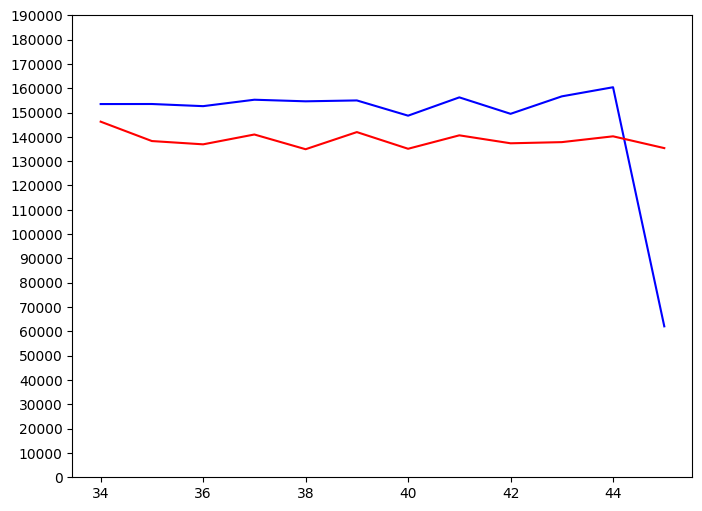

In [30]:
plt.figure(figsize=(8,6))
plt.plot(indices_to_validate, data_validation['kWh'], label="Original", color='blue')
plt.plot(indices_to_validate, forecast, label="Predição", color='red')
plt.yticks(np.arange(0,200000,step=10000))
plt.show()

In [31]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Ajustar SARIMA
model_sarima = SARIMAX(df['kWh'], order=(2,0,3), seasonal_order=(1,1,2,4))
model_sarima_fit = model_sarima.fit()

# 2. Prever múltiplos passos à frente
forecast_sarima = model_sarima_fit.forecast(steps=12)
print(forecast_sarima)


c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


2024-05-19    138495.061300
2024-05-26    134427.908004
2024-06-02    129746.744822
2024-06-09    135449.329442
2024-06-16    136889.156548
2024-06-23    131729.982893
2024-06-30    130827.812581
2024-07-07    135473.667493
2024-07-14    135365.428320
2024-07-21    131977.177020
2024-07-28    131539.002499
2024-08-04    135356.341385
Freq: W-SUN, Name: predicted_mean, dtype: float64


c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


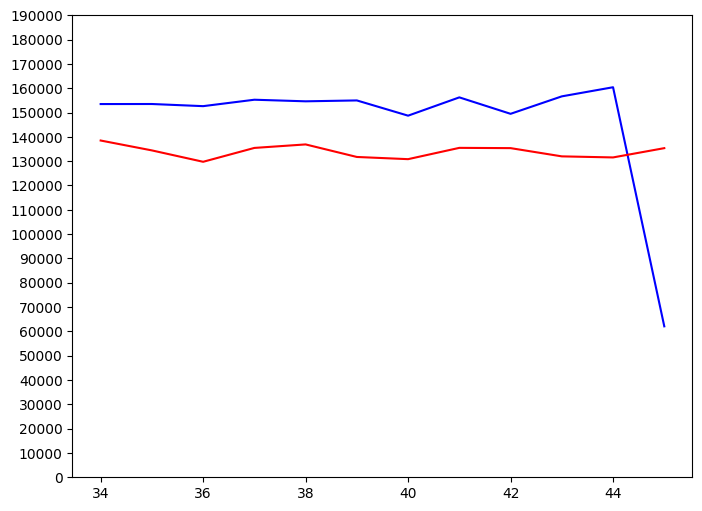

In [32]:
plt.figure(figsize=(8,6))
plt.plot(indices_to_validate, data_validation['kWh'], label="Original", color='blue')
plt.plot(indices_to_validate, forecast_sarima, label="Predição", color='red')
plt.yticks(np.arange(0,200000,step=10000))
plt.show()

In [33]:
mape = round(mean_absolute_percentage_error(forecast_sarima, data_validation['kWh']), 2)
print(f"mape",mape)

mae = round(mean_absolute_error(forecast_sarima, data_validation['kWh']), 2)
print(f"mae",mae)

mse = round(mean_squared_error(forecast_sarima, data_validation['kWh']), 2)
rmse = round(np.sqrt(mse), 2)
print(f"mse",mse)
print(f"rmse",rmse)

mape 0.19
mae 24778.49
mse 843558409.52
rmse 29044.08


In [34]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Ajustar ETS com tendência e sazonalidade
model_ets = ExponentialSmoothing(df['kWh'], trend='add', seasonal='add', seasonal_periods=4)
model_ets_fit = model_ets.fit()

# 2. Prever múltiplos passos à frente
forecast_ets = model_ets_fit.forecast(steps=12)
print(forecast_ets)

2024-05-19    142100.601126
2024-05-26    145516.943845
2024-06-02    134135.118509
2024-06-09    139996.947160
2024-06-16    140566.887778
2024-06-23    143983.230497
2024-06-30    132601.405161
2024-07-07    138463.233812
2024-07-14    139033.174431
2024-07-21    142449.517149
2024-07-28    131067.691813
2024-08-04    136929.520464
Freq: W-SUN, dtype: float64


c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
c:\Users\renantorres\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


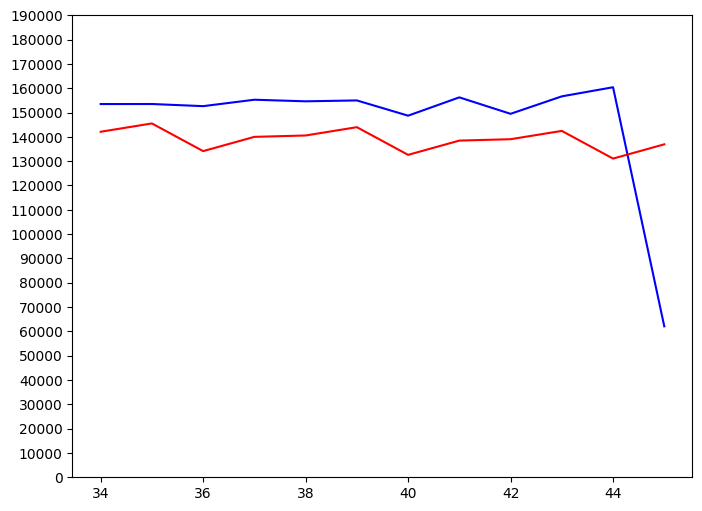

In [35]:
plt.figure(figsize=(8,6))
plt.plot(indices_to_validate, data_validation['kWh'], label="Original", color='blue')
plt.plot(indices_to_validate, forecast_ets, label="Predição", color='red')
plt.yticks(np.arange(0,200000,step=10000))
plt.show()

In [36]:
mape = round(mean_absolute_percentage_error(forecast_ets, data_validation['kWh']), 2)
print(f"mape",mape)

mae = round(mean_absolute_error(forecast_ets, data_validation['kWh']), 2)
print(f"mae",mae)

mse = round(mean_squared_error(forecast_ets, data_validation['kWh']), 2)
rmse = round(np.sqrt(mse), 2)
print(f"mse",mse)
print(f"rmse",rmse)

mape 0.15
mae 20076.8
mse 703115645.35
rmse 26516.33


In [37]:
from fbprophet import Prophet

# 1. Preparar os dados para o Prophet
df_prophet = df.reset_index().rename(columns={'timestamp': 'ds', 'kWh': 'y'})

# 2. Ajustar o modelo Prophet
model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model_prophet_fit = model_prophet.fit(df_prophet)

# 3. Prever múltiplas semanas à frente
future = model_prophet.make_future_dataframe(periods=5, freq='W')
forecast_prophet = model_prophet.predict(future)
print(forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12))


ModuleNotFoundError: No module named 'fbprophet'

In [ ]:
mape = round(mean_absolute_percentage_error(forecast_prophet, data_validation['kWh']), 2)
print(f"mape",mape)

mae = round(mean_absolute_error(forecast_prophet, data_validation['kWh']), 2)
print(f"mae",mae)

mse = round(mean_squared_error(forecast_prophet, data_validation['kWh']), 2)
rmse = round(np.sqrt(mse), 2)
print(f"mse",mse)
print(f"rmse",rmse)